In [2]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys 
import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
st_1 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm20_nep20.pt")
st_2 = CheckPoint.from_pt(path="../models/copy_nstudy/MLC_batchstudy_alph_dallstudy2_copy_perm20_nep20.pt")
st_3 = CheckPoint.from_pt(path="../models/copy_nstudy/MLC_batchstudy_alph_dallstudy3_copy_perm20_nep20.pt")
st_4 = CheckPoint.from_pt(path="../models/copy_nstudy/MLC_batchstudy_alph_dallstudy4_copy_perm20_nep20.pt")
st_5 = CheckPoint.from_pt(path="../models/copy_nstudy/MLC_batchstudy_alph_dallstudy5_copy_perm20_nep20.pt")

all_training_runs = [st_1, st_2, st_3, st_4, st_5]


In [ ]:
val_accs = pd.DataFrame()
for n, cp in enumerate(all_training_runs, start=1):
    df = pd.DataFrame(cp.val_acc_hist)
    df["n_study"] = n
    val_accs = pd.concat([val_accs, df])

,epoch,overall,copy,noncopy,extend_extend_succ,extend_group,extend_pred,extend_sequence,fix_alphabetic_seq,fix_extend,...,rr_interleave,rr_sort,rr_succ,shift,sort,sort_group,succ,in,out-of,n_study
0,1,0.432191,0.658676,0.205854,0.002555,0.000000,0.002667,0.567053,0.278360,0.224573,...,0.381317,0.569244,0.115562,0.0,0.589193,0.133610,0.116150,0.315612,0.069151,1
1,2,0.558550,0.674454,0.442721,0.000852,0.000943,0.000000,0.880795,0.327225,0.415785,...,0.894334,0.743415,0.849769,0.0,0.795707,0.562656,0.844869,0.724360,0.091941,1
2,3,0.597373,0.707798,0.487020,0.000852,0.003770,0.012444,0.902318,0.424084,0.543531,...,0.947167,0.615973,0.928351,0.0,0.874907,0.752697,0.898170,0.808151,0.087050,1
3,4,0.598113,0.695899,0.500392,0.000000,0.017908,0.005333,0.946192,0.446771,0.584215,...,0.937213,0.683942,0.949153,0.0,0.893412,0.773444,0.926810,0.828491,0.091745,1
4,5,0.603974,0.697816,0.510193,0.000000,0.006598,0.010667,0.942053,0.505236,0.604557,...,0.977029,0.625319,0.943760,0.0,0.891932,0.850622,0.924423,0.839563,0.099961,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,16,0.373722,0.374484,0.372957,0.000000,0.000000,0.000000,0.889351,0.646331,0.619324,...,0.997059,0.513633,0.240570,0.0,0.730107,0.932647,0.191150,0.584856,0.119462,5
16,17,0.366871,0.366729,0.367013,0.000000,0.000000,0.000000,0.889351,0.601814,0.639614,...,0.997794,0.505527,0.233864,0.0,0.755537,0.925515,0.153982,0.575267,0.117880,5
17,18,0.368825,0.368791,0.368859,0.000000,0.000000,0.000000,0.886023,0.647156,0.628986,...,1.000000,0.537951,0.230511,0.0,0.744873,0.877971,0.148673,0.577085,0.119759,5
18,19,0.368421,0.368791,0.368049,0.000000,0.000000,0.000000,0.906822,0.650453,0.610628,...,1.000000,0.460575,0.259011,0.0,0.757998,0.923930,0.152212,0.580722,0.113627,5


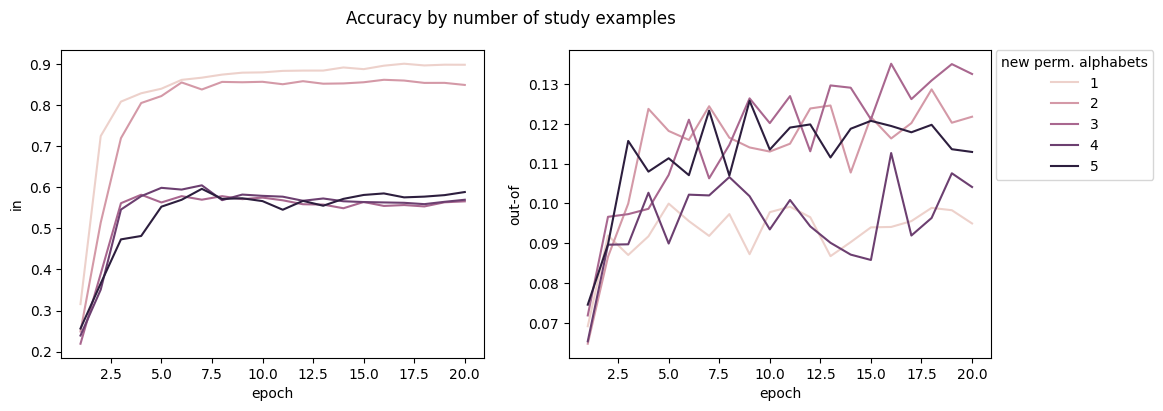

In [31]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
_ = sns.lineplot(val_accs, x="epoch", y="in", hue="n_study", ax=ax[0])
_ = ax[0].legend().remove()
_ = sns.lineplot(val_accs, x="epoch", y="out-of", hue="n_study", ax=ax[1])
_ = plt.suptitle("Accuracy by number of study examples")
_ = ax[1].legend(title="new perm. alphabets", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)

In [36]:
print("Final Overall Val. Accuracies")
val_accs[val_accs["epoch"]==20][["n_study", "overall"]]

Final Overall Val. Accuracies


,n_study,overall
19,1,0.624714
19,2,0.536501
19,3,0.361684
19,4,0.351655
19,5,0.371229
